# Añadir velocidades a la red OSMNX

Este notebook tiene la finalidad de pasar atributos de la red vial de TransCAD del Imeplan, a la red vial de OSMNX que es la definitiva para el proyecto SOFIAA.

In [15]:
# Importar librerías necesarias
import geopandas as gpd
import matplotlib.pyplot as plt
import osmnx as ox
import numpy as np
from shapely.geometry import LineString

## OSMNX Links

In [ ]:
osmnx_file = r'/Users/jeannettearjona/Library/CloudStorage/OneDrive-InstitutoTecnologicoydeEstudiosSuperioresdeMonterrey/Modelación Urbana - Red Vial Guadalajara/Insumos OSMNX/Visum/Edges/edges_visum.shp'
osmnx_links = gpd.read_file(osmnx_file)
osmnx_links.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 494896 entries, 0 to 494895
Data columns (total 27 columns):
 #   Column      Non-Null Count   Dtype   
---  ------      --------------   -----   
 0   u           494896 non-null  int64   
 1   v           494896 non-null  int64   
 2   key         494896 non-null  int64   
 3   osmid       494896 non-null  str     
 4   highway     492462 non-null  str     
 5   lanes       63780 non-null   str     
 6   name        302078 non-null  str     
 7   oneway      494896 non-null  bool    
 8   ref         4573 non-null    str     
 9   reversed    494896 non-null  str     
 10  length      494896 non-null  float64 
 11  bridge      2705 non-null    str     
 12  maxspeed    14238 non-null   str     
 13  access      54114 non-null   str     
 14  junction    2468 non-null    str     
 15  tunnel      1174 non-null    str     
 16  width       2598 non-null    str     
 17  service     4801 non-null    str     
 18  area        9 no

## TransCAD Links

In [17]:
transcad_file = r'/Users/jeannettearjona/Library/CloudStorage/OneDrive-InstitutoTecnologicoydeEstudiosSuperioresdeMonterrey/Modelación Urbana - Red Vial Guadalajara/Importacion TransCAD/Red Vial 2023 Python Cleaned/links_cleaned.shp'
transcad_links = gpd.read_file(transcad_file)
transcad_links.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 139228 entries, 0 to 139227
Data columns (total 63 columns):
 #   Column      Non-Null Count   Dtype   
---  ------      --------------   -----   
 0   ID          139228 non-null  int64   
 1   LENGTH      139228 non-null  float64 
 2   DIR         139228 non-null  int32   
 3   IVTT        139228 non-null  float64 
 4   DRIVE_TIME  139228 non-null  float64 
 5   CONST_DRIV  139228 non-null  float64 
 6   WALK_TIME   139228 non-null  float64 
 7   CONST_WALK  139228 non-null  float64 
 8   MODE_WALK   139228 non-null  float64 
 9   CAPACIDAD   139228 non-null  int64   
 10  CARRILES    139228 non-null  int64   
 11  ESTACIONAM  138560 non-null  float64 
 12  MUNICIPIO   139031 non-null  float64 
 13  CALLE       130274 non-null  str     
 14  TIPO        139223 non-null  float64 
 15  TRANSPORTE  139228 non-null  int64   
 16  JERARQUIA   42 non-null      float64 
 17  NOMBRE      106028 non-null  str     
 18  ABPCE       1907

### __Las columnas que nos interesan son:__
- __Limite_vel__: límite de velocidad establecido de la vialidad
- __CAPACIDAD__: Capacidad en vehículos por hora de la vialidad
- __Velocidad__: Promedio de velocidad de circulación de la vialidad calculado a partir de datos de uber

In [18]:
#Convertir a entero los valores de la columna 'Limite_vel' en el GeoDataFrame red_con_velocidades
transcad_links['Limite_vel'] = transcad_links['Limite_vel'].astype(int)
#Contar las filas para cada valor único de la columna 'Limite_vel' en el GeoDataFrame red_con_velocidades
transcad_links.groupby('Limite_vel').size()

Limite_vel
0        325
10        16
30    131153
40      4520
50      1059
60       569
80      1586
dtype: int64

Las que tienen velocidad 0 km/h son aquellos links por donde no se permite el paso de vehículos, como por ejemplo, calles peatonales. En transCAD era necesario agregarle una velocidad vehicular a estas calles por lo que al agregarles un límite de velocidad bajo el programa no les tomaba en cuenta para la asignación de tráfico.

Visualizar la red_con_velocidades con colores según los límites de velocidad

<Axes: >

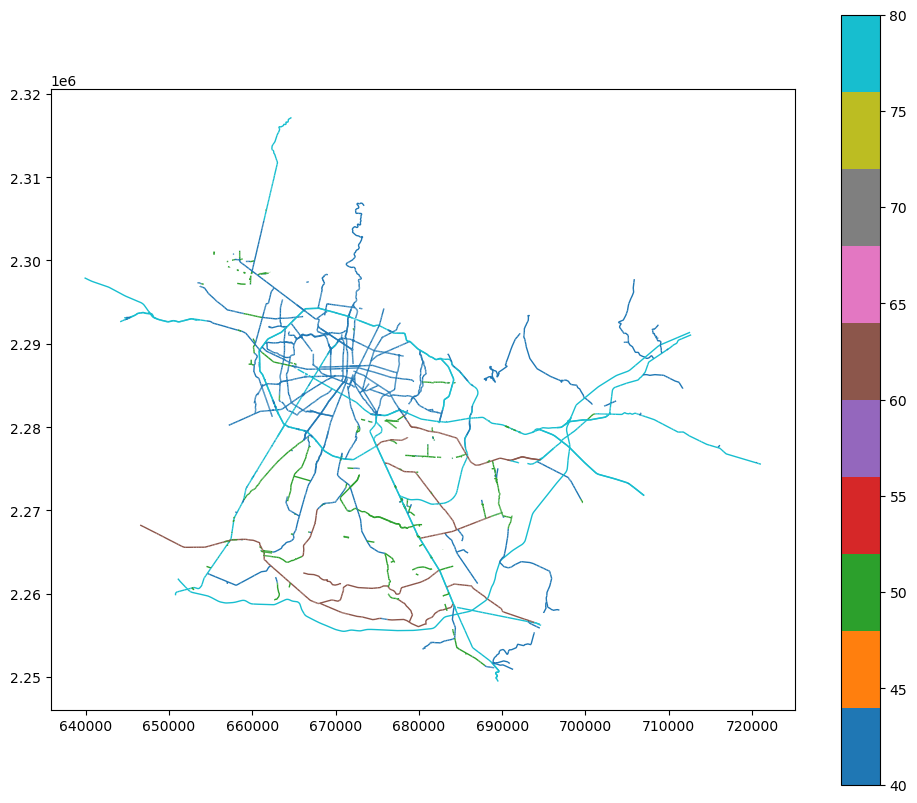

In [19]:
# Mapear tramos con velocidades mayores a 30 km/h
transcad_links[transcad_links["Limite_vel"] > 30].plot(
    column="Limite_vel",
    cmap="tab10",
    legend=True,
    figsize=(12, 10),
    linewidth=1
)

In [20]:
transcad_links = transcad_links[transcad_links["Limite_vel"] >= 40]

## Pasar atributos de TransCAD links a OSMNX links

(se usan los OSMNX previos al Visum import porque si se usan los de visum las geometrias salen mas fragmentadas)

La siguiente celda de código contiene el algoritmo para pasar las columnas seleccionadas de la red vial de Imeplan a la red OSMNX. Lo hace mediante un buffer y vinculando todos los links que queden dentro del buffer, pero además comparando contra el ángulo que forman los links contra lo que estamos midiendo, para así no incluir links que sean perpendiculares o crucen

In [21]:
# Configuraciones iniciales
GDF_A = osmnx_links          # Red destino (a la que le queremos pasar las columnas)
GDF_B = transcad_links          # Red fuente (de donde queremos extraer las columnas)

COLUMNAS = ["CAPACIDAD", "Velocidad_", "Limite_vel"]   # Columnas de GDF_B que queremos transferir a GDF_A

CRS_METRICO = "EPSG:32613"   # UTM zona 30N
BUFFER_M    = 25               # Radio del buffer en metros
MAX_ANGULO  = 35              # Diferencia máxima de ángulo permitida (grados)


# 1. Reproyectar a CRS métrico
a = GDF_A.to_crs(CRS_METRICO).copy().reset_index(drop=True)
b = GDF_B.to_crs(CRS_METRICO).copy().reset_index(drop=True)


# 2. Función: ángulo de un segmento (0–180°)
def angulo_linea(geom):
    """Devuelve el ángulo en grados del primer y último vértice (0–180°)."""
    try:
        coords = list(geom.coords) if geom.geom_type == "LineString" else \
                 list(geom.geoms[0].coords)
        p1, p2 = np.array(coords[0]), np.array(coords[-1])
        ang = np.degrees(np.arctan2(p2[1] - p1[1], p2[0] - p1[0])) % 180
        return ang
    except Exception:
        return np.nan

a["_angulo"] = a.geometry.apply(angulo_linea)
b["_angulo"] = b.geometry.apply(angulo_linea)
b["_idx_b"]  = b.index          # guardamos el índice original de B


# 3. Buffer + spatial join (candidatos dentro del buffer)
a_buf = a.copy()
a_buf["geometry"] = a.geometry.buffer(BUFFER_M)

# sjoin: encuentra todos los links de B que caen dentro del buffer de A
candidatos = gpd.sjoin(b[["_idx_b", "_angulo", "geometry"] + COLUMNAS],
                       a_buf[["geometry", "_angulo"]].rename(columns={"_angulo": "_angulo_a"}),
                       how="inner", predicate="within")
# predicate="within", el link de B debe estar completamente dentro del buffer


# 4. Filtro por diferencia de ángulo < MAX_ANGULO grados
def diff_angulo(a1, a2):
    diff = abs(a1 - a2) % 180
    return min(diff, 180 - diff)    # simétrico: 170° y 10° son lo mismo

candidatos["_diff_ang"] = candidatos.apply(
    lambda r: diff_angulo(r["_angulo"], r["_angulo_a"]), axis=1
)
candidatos = candidatos[candidatos["_diff_ang"] < MAX_ANGULO]


# 5. Si hay varios candidatos, quedarse con el más cercano (menor distancia entre geometrías originales)
idx_a_col = "index_right"    # columna generada por sjoin con el índice de A

candidatos["_dist"] = candidatos.apply(
    lambda r: b.loc[r["_idx_b"], "geometry"].distance(
              a.loc[r[idx_a_col], "geometry"]), axis=1
)

mejor = (candidatos
         .sort_values("_dist")
         .groupby(idx_a_col, sort=False)
         .first()
         .reset_index()
         .rename(columns={idx_a_col: "_idx_a"}))


# 6. Transferir columnas a GDF_A
resultado = GDF_A.copy()
resultado = resultado.merge(
    mejor[["_idx_a"] + COLUMNAS].set_index("_idx_a"),
    left_index=True, right_index=True, how="left"
)

print(f"Links de A con match encontrado: {mejor['_idx_a'].nunique()} / {len(GDF_A)}")
print(f"Links sin match (NaN):           {resultado[COLUMNAS[0]].isna().sum()}")

resultado.head(5)

Links de A con match encontrado: 11824 / 494896
Links sin match (NaN):           483072


,u,v,key,osmid,highway,lanes,name,oneway,ref,reversed,...,ToNodeNo,LinkNo,AllowedMod,Length_m,OneWay_1,Name_1,geometry,CAPACIDAD,Velocidad_,Limite_vel
0,267537966,7306651630,0,"[832652768, 619339782, 688424559, 188974544, 1...",motorway,"['3', '2']",Autopista Guadalajara - Morelia,True,MEX 15D;MEX 80D,False,...,103492,1,"{'B', 'C'}",4832.636188,1,Autopista Guadalajara - Morelia,"LINESTRING (-103.24632 20.61606, -103.24734 20...",2000.0,34.0,80.0
1,267537966,5837556433,0,694566994,motorway_link,1,NaN,True,NaN,False,...,15708,2,"{'B', 'C'}",146.226523,1,NaN,"LINESTRING (-103.24632 20.61606, -103.24648 20...",NaN,NaN,NaN
2,267538751,273140976,0,189118222,motorway,2,Autopista Guadalajara - Zapotlanejo,True,MEX 80D;MEX 90D,False,...,3,3,"{'B', 'C'}",520.548789,1,Autopista Guadalajara - Zapotlanejo,"LINESTRING (-103.1364 20.60565, -103.13432 20....",NaN,NaN,NaN
3,267538751,1746293763,0,907206852,motorway_link,1,Autopista Guadalajara - Morelia,True,MEX 15D,False,...,3068,4,"{'B', 'C'}",617.879708,1,Autopista Guadalajara - Morelia,"LINESTRING (-103.1364 20.60565, -103.1354 20.6...",NaN,NaN,NaN
4,273140976,1997658287,0,835083267,motorway,3,Autopista Guadalajara - Zapotlanejo,True,MEX 80D;MEX 90D,False,...,7341,5,"{'B', 'C'}",151.478387,1,Autopista Guadalajara - Zapotlanejo,"LINESTRING (-103.13185 20.60758, -103.13162 20...",NaN,NaN,NaN


In [8]:
# Configuraciones iniciales
GDF_OSMNX = osmnx_links                       # Red destino (a la que le queremos pasar las columnas)
GDF_TRANSCAD = transcad_main_avenues          # Red fuente (de donde queremos extraer las columnas)

COLUMNAS = ["CAPACIDAD", "Velocidad_", "Limite_vel"]   # Columnas de GDF_B que queremos transferir a GDF_A

CRS_METRICO = "EPSG:32613"   # UTM zona 30N
BUFFER_M    = 25               # Radio del buffer en metros
MAX_ANGULO  = 35              # Diferencia máxima de ángulo permitida (grados)


# 1. Reproyectar a CRS métrico
a = GDF_OSMNX.to_crs(CRS_METRICO).copy().reset_index(drop=True)
b = GDF_TRANSCAD.to_crs(CRS_METRICO).copy().reset_index(drop=True)


# 2. Función: ángulo de un segmento (0–180°)
def angulo_linea(geom):
    """Devuelve el ángulo en grados del primer y último vértice (0–180°)."""
    try:
        coords = list(geom.coords) if geom.geom_type == "LineString" else \
                 list(geom.geoms[0].coords)
        p1, p2 = np.array(coords[0]), np.array(coords[-1])
        ang = np.degrees(np.arctan2(p2[1] - p1[1], p2[0] - p1[0])) % 180
        return ang
    except Exception:
        return np.nan

a["_angulo"] = a.geometry.apply(angulo_linea)
b["_angulo"] = b.geometry.apply(angulo_linea)
b["_idx_b"]  = b.index          # guardamos el índice original de B


# 3. Buffer + spatial join (candidatos dentro del buffer)
a_buf = a.copy()
a_buf["geometry"] = a.geometry.buffer(BUFFER_M)

# sjoin: encuentra todos los links de B que caen dentro del buffer de A
candidatos = gpd.sjoin(b[["_idx_b", "_angulo", "geometry"] + COLUMNAS],
                       a_buf[["geometry", "_angulo"]].rename(columns={"_angulo": "_angulo_a"}),
                       how="inner", predicate="within")
# predicate="within", el link de B debe estar completamente dentro del buffer


# 4. Filtro por diferencia de ángulo < MAX_ANGULO grados
def diff_angulo(a1, a2):
    diff = abs(a1 - a2) % 180
    return min(diff, 180 - diff)    # simétrico: 170° y 10° son lo mismo

candidatos["_diff_ang"] = candidatos.apply(
    lambda r: diff_angulo(r["_angulo"], r["_angulo_a"]), axis=1
)
candidatos = candidatos[candidatos["_diff_ang"] < MAX_ANGULO]


# 5. Si hay varios candidatos, quedarse con el más cercano (menor distancia entre geometrías originales)
idx_a_col = "index_right"    # columna generada por sjoin con el índice de A

candidatos["_dist"] = candidatos.apply(
    lambda r: b.loc[r["_idx_b"], "geometry"].distance(
              a.loc[r[idx_a_col], "geometry"]), axis=1
)

mejor = (candidatos
         .sort_values("_dist")
         .groupby(idx_a_col, sort=False)
         .first()
         .reset_index()
         .rename(columns={idx_a_col: "_idx_a"}))


# 6. Transferir columnas a GDF_A
resultado = GDF_OSMNX.copy()
resultado = resultado.merge(
    mejor[["_idx_a"] + COLUMNAS].set_index("_idx_a"),
    left_index=True, right_index=True, how="left"
)

print(f"Links de OSMNX con match encontrado: {mejor['_idx_a'].nunique()} / {len(GDF_OSMNX)}")
print(f"Links sin match (NaN):           {resultado[COLUMNAS[0]].isna().sum()}")

resultado.head(5)

Links de OSMNX con match encontrado: 11824 / 494896
Links sin match (NaN):           483072


,u,v,key,osmid,highway,lanes,name,oneway,ref,reversed,...,Modes,TsysCodes,Length_m,length_km,OneWay_1,Name_1,geometry,CAPACIDAD,Velocidad_,Limite_vel
0,267537966,7306651630,0,"[832652768, 619339782, 688424559, 188974544, 1...",motorway,"['3', '2']",Autopista Guadalajara - Morelia,True,MEX 15D;MEX 80D,False,...,"BUS,CAR","B,C",4832.636188,4.827825,1,Autopista Guadalajara - Morelia,"LINESTRING (-103.24632 20.61606, -103.24734 20...",2000.0,34.0,80.0
1,267537966,5837556433,0,694566994,motorway_link,1,NaN,True,NaN,False,...,"BUS,CAR","B,C",146.226523,0.146029,1,NaN,"LINESTRING (-103.24632 20.61606, -103.24648 20...",NaN,NaN,NaN
2,267538751,273140976,0,189118222,motorway,2,Autopista Guadalajara - Zapotlanejo,True,MEX 80D;MEX 90D,False,...,"BUS,CAR","B,C",520.548789,0.520237,1,Autopista Guadalajara - Zapotlanejo,"LINESTRING (-103.1364 20.60565, -103.13432 20....",NaN,NaN,NaN
3,267538751,1746293763,0,907206852,motorway_link,1,Autopista Guadalajara - Morelia,True,MEX 15D,False,...,"BUS,CAR","B,C",617.879708,0.617213,1,Autopista Guadalajara - Morelia,"LINESTRING (-103.1364 20.60565, -103.1354 20.6...",NaN,NaN,NaN
4,273140976,1997658287,0,835083267,motorway,3,Autopista Guadalajara - Zapotlanejo,True,MEX 80D;MEX 90D,False,...,"BUS,CAR","B,C",151.478387,0.151355,1,Autopista Guadalajara - Zapotlanejo,"LINESTRING (-103.13185 20.60758, -103.13162 20...",NaN,NaN,NaN


<Axes: >

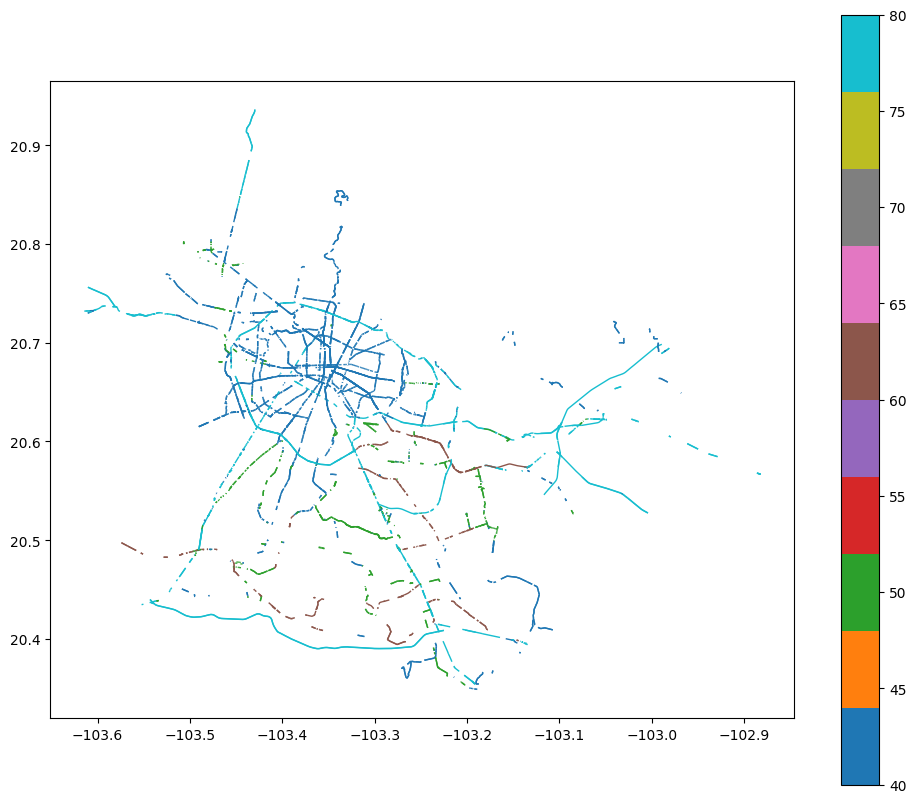

In [ ]:
# Visualizar para valores de Limite_vel mayores 30 para mejor lectura
resultado[resultado["Limite_vel"] > 30].plot(
    column="Limite_vel",
    cmap="tab10",
    legend=True,
    figsize=(12, 10),
    linewidth=1
)

Exportar la capa

In [ ]:
shp_salida = '../data/buffer_velocidades_capacidad/edges_osnmx_con_velocidades_y_capacidad2.shp'
resultado.to_file(shp_salida)